In [268]:
import pandas as pd
import numpy as np

In [269]:
flights = pd.read_csv('epstein-flights-2026-04-01.csv')
flights = flights.rename(columns={'Date': 'date', 'Origin': 'origin', 'Destination': 'destination', 'Aircraft': 'aircraft', 'Passengers': 'passengers', 'Pilot': 'pilot', 'Notes': 'notes'})
flights = flights.sort_values(by='date', ascending=True).reset_index(drop=True)

In [270]:
flights['date'] = pd.to_datetime(flights['date'])

In [271]:
emails = pd.read_json('emails_with_metadata.json')
emails = emails.sort_values(by='date', ascending=True).reset_index(drop=True)

<Axes: xlabel='date'>

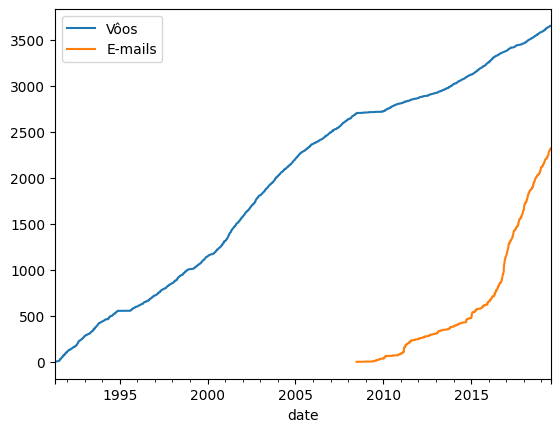

In [272]:
flights.groupby(['date'])[['origin']].count().cumsum().resample('D').ffill().rename(columns={'origin':'Vôos'}).join(
    emails.groupby(['date'])[['email_text']].count().cumsum().resample('D').ffill().rename(columns={'email_text':'E-mails'}),
    how='outer'
).plot()

In [273]:
dt = flights.groupby(['date'])[['origin']].count().resample('D').ffill().join(emails.groupby(['date'])[['email_text']].count().resample('D').ffill(), on='date')

<Axes: xlabel='date'>

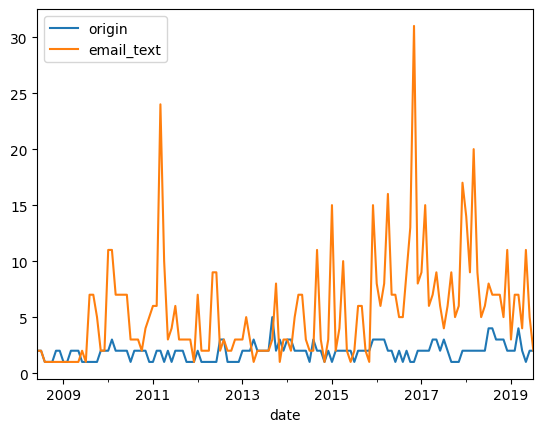

In [274]:
dt.to_period('M').groupby(['date']).max()[emails['date'].min():].plot()

In [337]:
names = pd.concat([emails['people_mentioned'].explode(),
                   flights['passengers'].str.split(';').explode()]
                  ).unique()
people = pd.DataFrame(columns=['name', 'email_frequency', 'flight_frequency', 'first_email', 'first_flight'])
people['name'] = names

In [ ]:
people['email_frequency'] = people['name'].apply(lambda x: emails['people_mentioned'].apply(lambda y: x in y).sum())
people['flight_frequency'] = people['name'].apply(lambda x: flights['passengers'].dropna().str.split(';').apply(lambda y: x in y).sum())
people['first_email'] = people['name'].apply(
    lambda x: emails
    .loc[emails['people_mentioned'].apply(lambda y: x in y)
         ].first_valid_index()
    ).apply(lambda x: emails.iloc[int(x)]['date'] if not np.isnan(x) else np.nan)
people['first_flight'] = people['name'].apply(
    lambda x: flights[['passengers', 'date']].dropna()
    .loc[flights['passengers'].dropna().str.split(';').apply(lambda y: x in y)
         ].first_valid_index()
    ).apply(lambda x: flights.iloc[int(x)]['date'] if not np.isnan(x) else np.nan)

In [347]:
people

,name,email_frequency,flight_frequency,first_email,first_flight
0,Kirk Blouin,2,0,2008-06-26,NaT
1,John Page,4,0,2008-06-26,NaT
2,Rob Walton,2,0,2008-06-26,NaT
3,Abe Gosman,4,0,2008-06-26,NaT
4,Ray Royce,2,0,2008-06-26,NaT
...,...,...,...,...,...
5259,Darren Rothell,0,1,NaT,2013-05-22
5260,Billy Dimauro,0,2,NaT,2013-07-17
5261,Bd,0,4,NaT,2013-08-03
5262,1 Passenger,0,2,NaT,2014-03-23


In [348]:
people.loc[(people['email_frequency'] > 0) & (people['flight_frequency'] > 0)]

,name,email_frequency,flight_frequency,first_email,first_flight
20,Jeffrey Epstein,1810,1005,2009-04-18,1991-07-26
37,Bill Clinton,260,14,2009-06-19,2002-02-09
65,Ghislaine Maxwell,96,42,2009-08-11,1992-01-05
102,Bill Gates,51,1,2009-10-31,2013-03-01
228,Gerald Lefcourt,10,2,2010-02-26,2006-12-21
245,Alan Dershowitz,73,3,2010-02-26,2004-02-05
810,Jeffrey,5,9,2011-04-26,1991-07-29
1951,Larry Visoski,44,278,2014-06-07,2001-08-30
3888,John Roberts,1,2,2018-11-21,2010-03-22


In [443]:
from sklearn.feature_extraction.text import TfidfVectorizer
import re

In [440]:
def last_match(text):
    last_pos = 0
    for match in re.finditer(r'((wrote:)|(To:)|(Subject:)|(Importance:)|(Sent:(.|\n)*?(AM|PM))).*?\n', text):
        last_pos = match.end()
    return text[last_pos:]

In [441]:
emails['email_text'] = emails['email_text'].apply(last_match).str.replace('\n', ' ')

In [436]:
emails['email_text'].iloc[0]

"Kirk: We had our June monthly ARCOM meeting yesterday. You likely know that ARCOM is working with Mr. Trump to re-install a hedge on his North County Road property. I believe this case is now pending in front of Code Enforcement. In May, ARCOM approved a plan to replace the former hedge with silver buttonwood shrubbery, which would additionally be back-planted with silver buttonwood trees....the overall effect would be an eventual 20' high screen. The shrubs have been planted, but yesterday attorney Ray Royce asked for postponing the trees until the end of the Hurricane season. ARCOM said NO and directed the attorney and landscaper to get the trees in ASAP. Also, more shrubbery was required at the main entry (north side) to match the newly installed hedge on the south side. As the meeting was ending, the Commissioners asked for one of two things. They asked that either 1) a quick written report from Code Enforcement be made available to them at their next meeting on July 23 (9:00 a.m.

In [454]:
vectorizer = TfidfVectorizer()
vector = vectorizer.fit_transform(emails['email_text'])

In [470]:
words = pd.DataFrame(columns=[1,2,3,4,5])

In [ ]:
X_tfidf = vector.toarray()
vocab = vectorizer.vocabulary_

reverse_vocab = {v:k for k,v in vocab.items()}

feature_names = vectorizer.get_feature_names_out()

idx = X_tfidf.argsort(axis=1)
tfidf_max5 = idx[:,-5:]

words[[1,2,3,4,5]] = [[reverse_vocab.get(item) for item in row] for row in tfidf_max5 ]

In [493]:
pd.DataFrame([[[reverse_vocab.get(item) for item in row] for row in tfidf_max5 ]]).transpose().explode(0).value_counts().head(50)

0            
the              1139
and               844
communication     789
this              686
is                653
of                147
landon             94
to                 88
epstein            85
jr                 81
thomas             71
that               67
mr                 57
she                54
he                 46
or                 43
we                 38
origins            31
asu                31
krauss             27
her                27
his                24
was                23
oversight          23
you                23
house              22
tax                20
zynga              20
zygocki            20
email              19
message            18
ghislaine          17
reuters            15
trump              15
bannon             14
hoffenberg         14
book               14
palm               14
all                14
your               14
asst               13
sex                13
jeffrey            13
flipboard          13
claims            